## Plot the fundamental time series

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Set parameters

In [2]:
#stat = 'integral'#'integral'#'mean'
#freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['tas','fgco2','nbp','co2mass','fco2antt']#,'dissic','cLand'] # ,'cLand','dissic'.  # 'tas','tos',
models = ['ACCESS-ESM1-5','MIROC-ES2L','GFDL-ESM2M','IPSL-CM6-ESMCO2','NorESM2-LM','GISSE2.1-G-CC2','EC-Earth3-ESM-1','CESM2','UKESM1-2']#]#,'IPSL-CM6-ESMCO2']#,'GFDL-ESM2M','NorESM2-LM','UKESM1-2','EC-Earth3-ESM-1']#['GISSE2.1-G-CC2'].   #]#, ]#, # 
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1
root_dir = f'./../01_postprocessed_data/global_time_series'

correct_for_piCs = dict()
correct_for_piCs['NorESM2-LM'] = 'no'
correct_for_piCs['GFDL-ESM2M'] = 'both'
correct_for_piCs['IPSL-CM6-ESMCO2'] = 'both'
correct_for_piCs['GISSE2.1-G-CC2'] = 'both'
correct_for_piCs['EC-Earth3-ESM-1'] = 'both'
correct_for_piCs['MIROC-ES2L'] = 'both'
correct_for_piCs['CESM2'] = 'both'
correct_for_piCs['ACCESS-ESM1-5'] = 'no'
correct_for_piCs['UKESM1-2'] = 'no'


model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'monthly'#'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

## Conversions

In [3]:
def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['gC/m^2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cSoil' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cVeg' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'dissic' and stat == 'integral' and vert_stat == 'integral' and da.units in ['mol m-3 x m x m2']:
        converter = 12.0107 /1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
        
    elif varia == 'co2mass' and stat is None and vert_stat is None and da.units in ['kg']:
        converter = 12.0107 / 44.011 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'co2mass' and stat == 'integral' and vert_stat is None and da.units in ['kg CO2/m2 x m2']:   # this case corresponds to NASA-GISS
        converter = 12.0107 / 44.011 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
        
    elif varia == 'fco2antt' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s','kg s-1 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and vert_stat is None and da.units in ['gC/m^2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fgco2' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fgco2' and stat == 'integral' and vert_stat is None and da.units in ['mmol/m^3 cm/s x m2 x s']:
        converter = 10**-5 * 12.0107/ 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da

    return da_conv

def get_stat(varia,model):

    # default settings
    if varia in ['tas','tos']:
        stat = 'mean'
    elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter','dissic','fco2antt']:
        stat = 'integral'
    elif varia in ['co2mass']:
        stat = None

    # overwrite some choices
    if model == 'GISSE2.1-G-CC2':
        if varia == 'co2mass':
            stat = 'integral'
    
    return stat


def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat
    
def get_infix(varia,default=True):
    infix_base = 'vertical_'
    if default == True:
        if varia in ['dissic']:
            infix = infix_base+'integral_'
        else:
            infix = ''
    else:
        infix = ''
    return infix    

def get_suffix(varia,default=True):
    if default == True:
        if varia in ['fco2antt','fgco2','nbp']:
            suffix = '_cumulated'
        else:
            suffix = ''
    else:
        suffix = ''
    return suffix    

None
0198-12-31 00:00:00
0160-12-31 00:00:00
0248-12-31 00:00:00
None
None
None
None
0231-12-31 00:00:00
0166-12-31 00:00:00
0281-12-31 00:00:00
None
None
None
None
0220-12-31 00:00:00
0164-12-31 00:00:00
0270-12-31 00:00:00
None
None
None
None
0249-12-31 00:00:00
0176-12-31 00:00:00
0299-12-31 00:00:00
None
None
None
None
0224-12-31 00:00:00
0168-12-31 00:00:00
0274-12-31 00:00:00
None
None
None
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
0294-12-31 00:00:00
working on server spirit
working on server spirit
0161-12-31 00:00:00
working on server spirit
working on server spirit
0344-12-31 00:00:00
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
None
None
0218-12-31 00:00:00
0168-12-31 00:00:00
0268-12-31 00:00:00
None
None
None
0441-12-31 00:00:00
0247-12-31 00:00:00
0182-12-31 00:00:00
0297-12-31 00:00:00
None
None


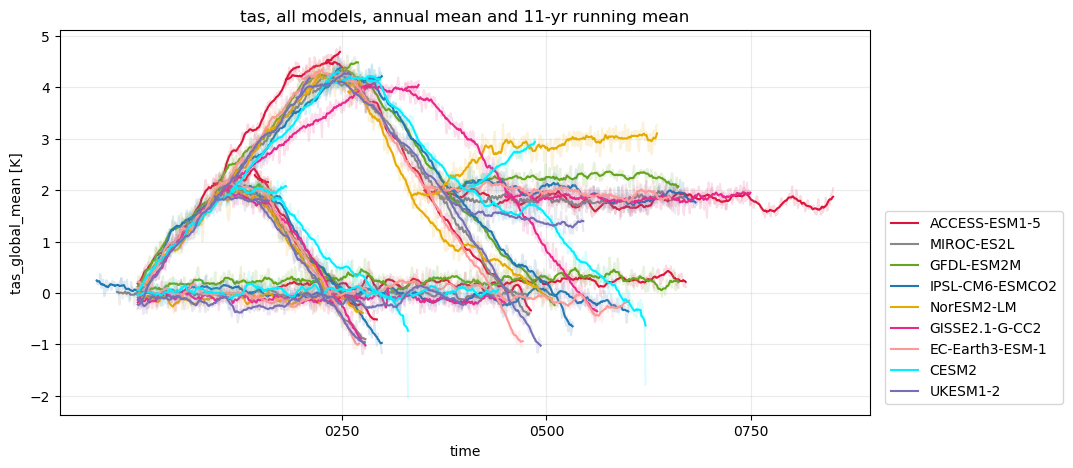

None
0198-12-31 00:00:00
0160-12-31 00:00:00
0248-12-31 00:00:00
None
None
None
None
0231-12-31 00:00:00
0166-12-31 00:00:00
0281-12-31 00:00:00
None
None
None
None
0220-12-31 00:00:00
0164-12-31 00:00:00
0270-12-31 00:00:00
None
None
None
None
0249-12-31 00:00:00
0176-12-31 00:00:00
0299-12-31 00:00:00
None
None
None
None
0224-12-31 00:00:00
0168-12-31 00:00:00
0274-12-31 00:00:00
None
None
None
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
0294-12-31 00:00:00
working on server spirit
working on server spirit
0161-12-31 00:00:00
working on server spirit
working on server spirit
0344-12-31 00:00:00
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
None
None
0218-12-31 00:00:00
0168-12-31 00:00:00
0268-12-31 00:00:00
None
None
None
0441-12-31 00:00:00
0247-12-31 00:00:00
0182-12-31 00:00:00
0297-12-31 00:00:00
None
None


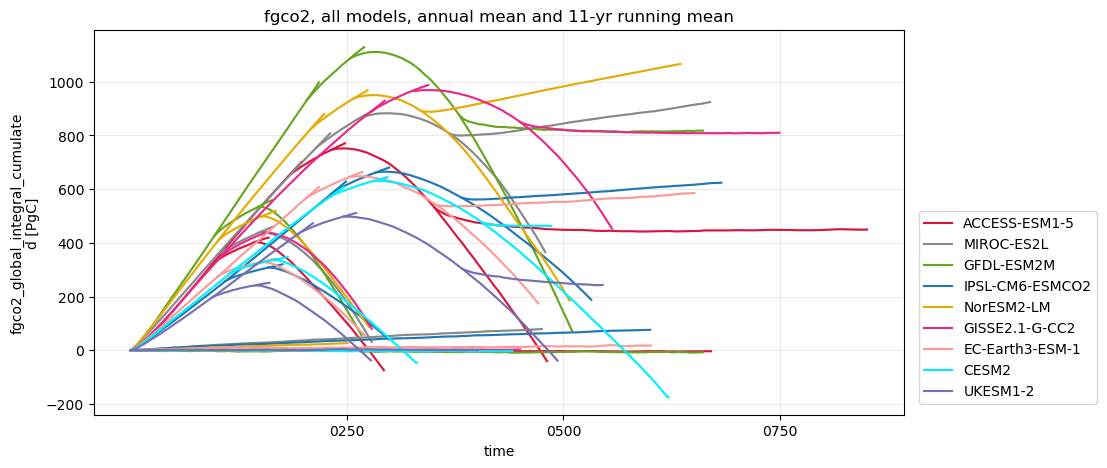

None
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
None
0231-12-31 00:00:00
0166-12-31 00:00:00
0281-12-31 00:00:00
None
None
None
None
0220-12-31 00:00:00
0164-12-31 00:00:00
0270-12-31 00:00:00
None
None
None
None
0249-12-31 00:00:00
0176-12-31 00:00:00
0299-12-31 00:00:00
None
None
None
None
0224-12-31 00:00:00
0168-12-31 00:00:00
0274-12-31 00:00:00
None
None
None
working on server spirit
working on server spirit
None
working on server spirit
w

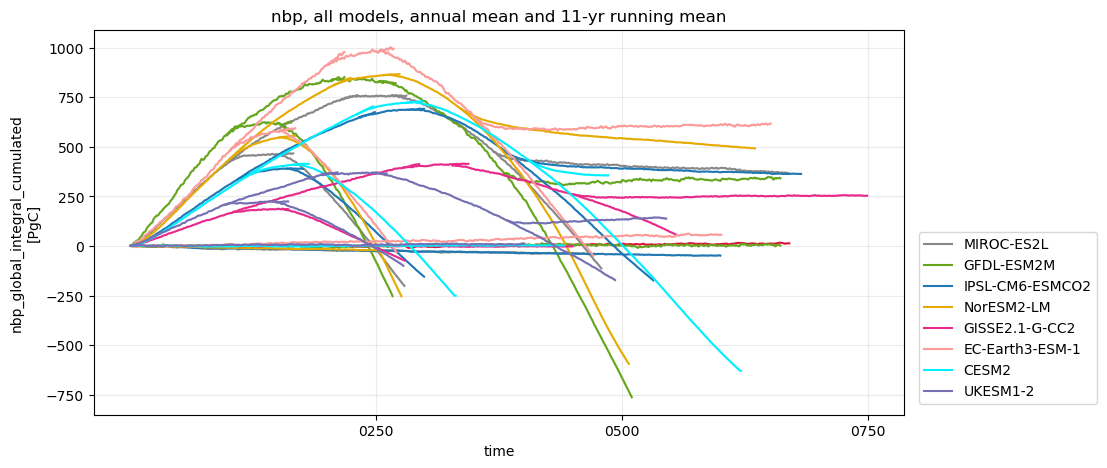

None
0198-12-31 00:00:00
0160-12-31 00:00:00
0248-12-31 00:00:00
None
None
None
None
0231-12-31 00:00:00
0166-12-31 00:00:00
0281-12-31 00:00:00
None
None
None
None
0220-12-31 00:00:00
0164-12-31 00:00:00
0270-12-31 00:00:00
None
None
None
None
0249-12-31 00:00:00
0176-12-31 00:00:00
0299-12-31 00:00:00
None
None
None
None
0224-12-31 00:00:00
0168-12-31 00:00:00
0274-12-31 00:00:00
None
None
None
working on server spirit
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global integral.
working on server spirit
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl4p0, monthly, global integral.
working on server spirit
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
w

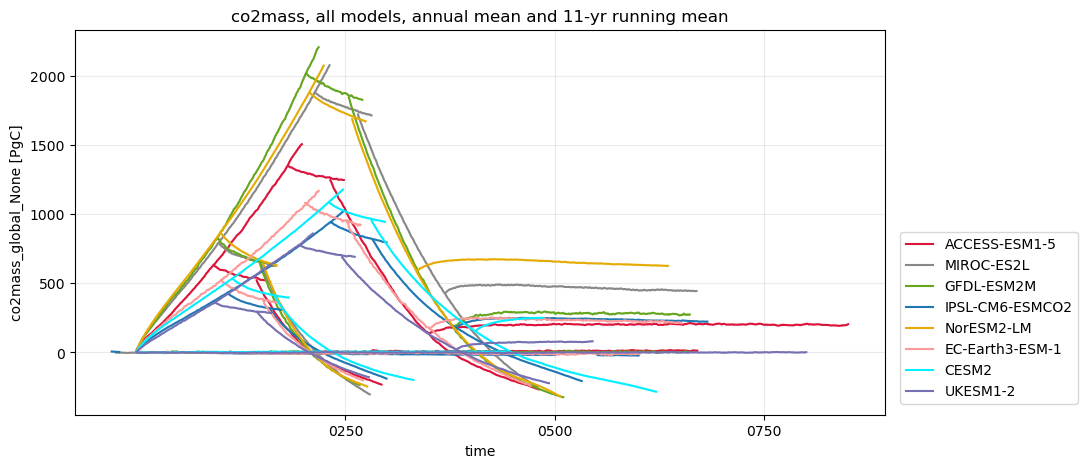

None
0198-12-31 00:00:00
0160-12-31 00:00:00
0248-12-31 00:00:00
None
None
None
None
0231-12-31 00:00:00
0166-12-31 00:00:00
0281-12-31 00:00:00
None
None
None
None
0220-12-31 00:00:00
0164-12-31 00:00:00
0270-12-31 00:00:00
None
None
None
None
0249-12-31 00:00:00
0176-12-31 00:00:00
0299-12-31 00:00:00
None
None
None
None
0224-12-31 00:00:00
0168-12-31 00:00:00
0274-12-31 00:00:00
None
None
None
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
0294-12-31 00:00:00
working on server spirit
working on server spirit
0161-12-31 00:00:00
working on server spirit
working on server spirit
0344-12-31 00:00:00
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
None
working on server spirit
working on server spirit
None
None
0218-12-31 00:00:00
0168-12-31 00:00:00
0268-12-31 00:00:00
None
None
None
0441-12-31 00:00:00
0247-12-31 00:00:00
0182-12-31 00:00:00
0297-12-31 00:00:00
None
None


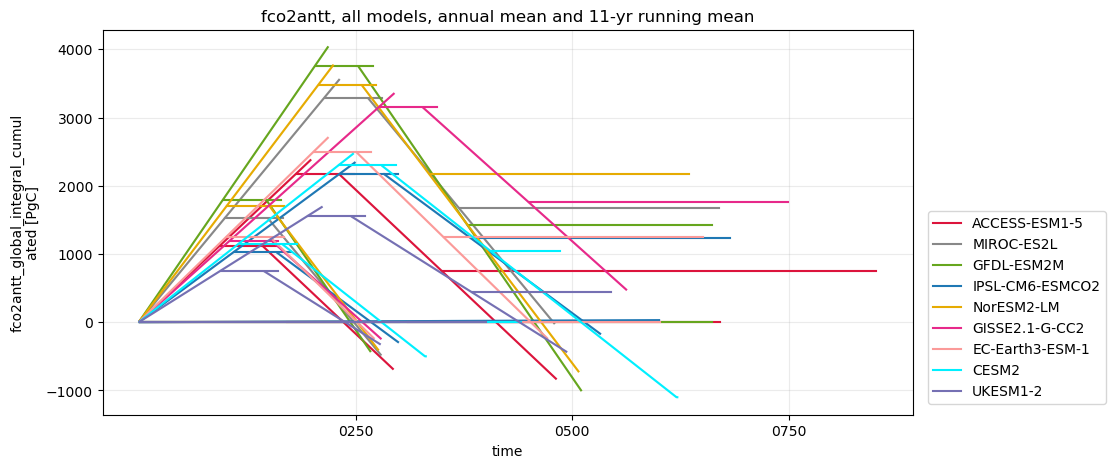

In [4]:
def get_reference_value(varia,model):
    freq_input = get_freq_input(model)
    stat = get_stat(varia,model)
    vert_stat = get_vert_stat(varia,default=True)
    mgrab = MODELgrabber.get_grabber(model)
    if model == 'GISSE2.1-G-CC2':
        member = mgrab.get_member('esm-piControl')
    else:
        member = mgrab.get_member()
    infix = get_infix(varia,default=True)
    suffix = get_suffix(varia,default=True)
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'

    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    
    if varia == 'tas':
        annual_stat = global_stat.resample(time="1YS").mean()
    else:
        annual_stat = global_stat.resample(time="1YS").first()

    if model == 'ACCESS-ESM1-5':
        reference_value = annual_stat.sel(time=f'{ref_year+170:04d}-01-01').values
    else:
        try:
            reference_value = annual_stat.sel(time=f'{ref_year:04d}-01-01').values
        except:
            reference_value = annual_stat.sel(time=f'{ref_year+1:04d}-01-01').values



    return reference_value


running_mean_years = 11

all_annual_stats = dict()
for varia in varias:
    all_annual_stats[varia] = dict()
    fig, ax = plt.subplots(figsize=(12,5))
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia,model)
        vert_stat = get_vert_stat(varia,default=True)
        mgrab = MODELgrabber.get_grabber(model)
        infix = get_infix(varia,default=True)
        suffix = get_suffix(varia,default=True)
        #print(varia,model)
        #print(varia,model,reference_value)
        #color = model_dict[model].color_id
        annual_stats = dict()
        for run in runs:
            if model == 'GISSE2.1-G-CC2' and run == 'esm-piControl' and varia == 'co2mass':
                continue
            if model == 'GISSE2.1-G-CC2':
                member = mgrab.get_member(run)
            else:
                member = mgrab.get_member()
            try:
                reference_value = get_reference_value(varia,model)
                #print(reference_value)
                color = model_dict[model].color_id#run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
                global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
                #print(global_stat.values)
                #print(global_stat.time)
    
                if varia == 'tas':
                    annual_stat = global_stat.resample(time="1YS").mean()
                else:
                    annual_stat = global_stat.resample(time="1YS").last()
    
                #if varia == 'co2mass':
                #    offsetter = get_offset_value(varia,model,reference_value)
                #    annual_stat = annual_stat + offsetter
    
                # correct for reference value
                annual_stat = annual_stat - reference_value
                
                
                annual_stat.attrs['units'] = global_stat.units
                
                # convert
                annual_stat = convert_units(varia,stat,annual_stat)
    
                # get the start and end
                time_slice = TimeOperator.get_time_start_and_end(model,run,model_dict,ref_year=ref_year)
                annual_stat = annual_stat.sel(time=time_slice)
                
                
                # if model == 'GISS' and variable is fco2antt, divide multiply with 12.0107 / 44.011 (is erroneously reported as kgCO2/m2/s instead of kgC/m2/s)
                #if model == 'GISSE2.1-G-CC2':
                #    if varia == 'fco2antt':
                #        annual_stat = annual_stat * 12/44 # 12.0107/44.011 # was the case for the annual data
                
                # put into dictionary
                annual_stats[run] = annual_stat
    
                if run == 'esm-up2p0':
                    label=model
                else:
                    label=''
                annual_stat.plot(alpha=.15,color=color)#,label=run)
                if varia in ['tas']:
                    annual_stat.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
                else:
                    annual_stat.plot(alpha=1,color=color,label=label)#,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
        all_annual_stats[varia][model] = annual_stats    
    ax.set_title(f'{varia}, all models, annual mean and {running_mean_years}-yr running mean')
    ax.grid(alpha=0.25)
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.show()

## Plot all in one figure

In [5]:
def first_zero_crossing(da):
    """
    Return first time where data crosses zero.
    """

    values = da.values

    # indices where sign changes
    idx = np.where(np.diff(np.sign(values)) != 0)[0]

    if len(idx) == 0:
        return None

    return da.time[idx[0] + 1]

def first_zero_crossing(da):
    """
    Return the first time where the data crosses zero, ignoring NaNs.
    """
    valid = da.notnull()
    da = da.where(valid, drop=True)

    values = da.values

    idx = np.where(np.diff(np.sign(values)) != 0)[0]

    if len(idx) == 0:
        return None

    return da.time[idx[0] + 1]

working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
working on server spirit
workin

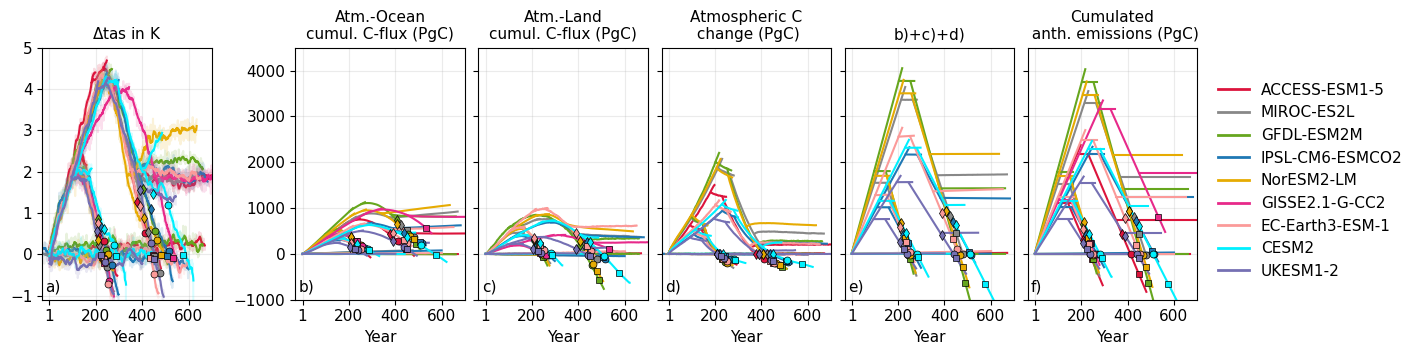

In [6]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 11

plt.rcParams['font.size']=11
fig = plt.figure(figsize=(14, 3.5))

# ============================================================
# layout
# ============================================================

gs = fig.add_gridspec(
    1,
    6,
    width_ratios=[1, 1, 1, 1, 1, 1],
    wspace=0.08,
)

# first axis independent
ax1 = fig.add_subplot(gs[0, 0])

# shared-y group
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2], sharey=ax2)
ax4 = fig.add_subplot(gs[0, 3], sharey=ax2)

# budget panel now in 5th column
ax5 = fig.add_subplot(gs[0, 4], sharey=ax2)

# final panel
ax6 = fig.add_subplot(gs[0, 5], sharey=ax2)

# shift shared group rightward
shift = 0.05

for ax in [ax2, ax3, ax4, ax5, ax6]:
    pos = ax.get_position()
    ax.set_position([
        pos.x0 + shift,
        pos.y0,
        pos.width,
        pos.height,
    ])

axes = [ax1, ax2, ax3, ax4, ax5, ax6]

for ax in axes:
    pos = ax.get_position()
    ax.set_position([
        pos.x0 - 0.1,
        pos.y0 + 0.05,
        pos.width,
        pos.height -0.05,
    ])

# put budget in 5th slot
plot_varias = [
    "tas",
    "fgco2",
    "nbp",
    "co2mass",
    "budget",
    "fco2antt",
]

# ============================================================
# formatting constants
# ============================================================

xlim = [
    cftime.DatetimeProlepticGregorian(-30, 1, 1),
    cftime.DatetimeProlepticGregorian(700, 1, 1),
]

xticks = [
    cftime.DatetimeProlepticGregorian(1, 1, 1),
    cftime.DatetimeProlepticGregorian(200, 1, 1),
    cftime.DatetimeProlepticGregorian(400, 1, 1),
    cftime.DatetimeProlepticGregorian(600, 1, 1),
]

# ============================================================
# legend handles
# ============================================================

legend_handles = {}

# ============================================================
# plotting
# ============================================================

for ax, varia in zip(axes, plot_varias):

    is_tas = varia == "tas"

    for model in models:

        freq_input = get_freq_input(model)
        stat = get_stat(varia, model) if varia != "budget" else "sum"

        color = model_dict[model].color_id

        # clean legend handle once per model
        if model not in legend_handles:

            legend_handles[model] = Line2D(
                [0],
                [0],
                color=color,
                lw=2,
                alpha=1,
                label=model,
            )

        for run in runs:
            if model == 'GISSE2.1-G-CC2' and run == 'esm-piControl':
                continue
                
            if model == 'GISSE2.1-G-CC2':
                member = MODELgrabber.get_grabber(model).get_member(run)
            else:
                member = MODELgrabber.get_grabber(model).get_member()

            try:

                # synthetic budget panel
                if varia == "budget":
    
                    annual_stat = (
                        all_annual_stats["fgco2"][model][run]
                        + all_annual_stats["nbp"][model][run]
                        + all_annual_stats["co2mass"][model][run]
                    )
    
                else:
    
                    annual_stat = all_annual_stats[varia][model][run]
    
    
                # ------------------------------------------------
                # zero-crossing time from cumulative emissions
                # ------------------------------------------------
                
                emissions = all_annual_stats["fco2antt"][model][run]
                zero_time_emissions = first_zero_crossing(emissions)
    
                if model != 'GISSE2.1-G-CC2':
                    co2_mass = all_annual_stats["co2mass"][model][run]
                    zero_time_co2mass = first_zero_crossing(co2_mass)    
    
                #ref_temp = all_annual_stats["tas"][model]["esm-up2p0"].resample(time="YS").mean().isel(time=0)
                #print(all_annual_stats["tas"][model]["esm-up2p0"].resample(time="YS").mean())
                #annual_temp = all_annual_stats["tas"][model][run].resample(time="YS").mean() #- ref_temp #all_annual_stats["tas"][model][run].resample(time="YS").mean() - all_annual_stats["tas"][model]['esm-up2p0'].resample(time="YS").isel(year=0)
                annual_temp_rm31 = all_annual_stats["tas"][model][run]#.rolling(time=31, center=True).mean()
                zero_time_temp = first_zero_crossing(annual_temp_rm31)   
                
                # raw series
                ax.plot(
                    annual_stat.time,
                    annual_stat,
                    alpha=0.15 if is_tas else 1,
                    color=color,
                )
    
                # smoothed tas overlay
                if is_tas:
    
                    smooth = annual_stat.rolling(
                        time=running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
    
                    ax.plot(
                        smooth.time,
                        smooth,
                        alpha=1,
                        color=color,
                    )

            except Exception:
            
                print(
                    f"Nothing to plot for "
                    f"{varia}, {model}, {member}, {run}, "
                    f"{freq_input}, global {stat}."
                )
                zero_time_emissions = None
                zero_time_co2mass = None
                zero_time_temp = None


            # ------------------------------------------------
            # marker at net-zero year
            # ------------------------------------------------

            if run in ['esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0']:
                
                if zero_time_emissions is not None:
                
                    try:
                
                        marker_value = annual_stat.sel(time=zero_time_emissions)
                
                        ax.plot(
                            zero_time_emissions,
                            marker_value,
                            marker='o',
                            markersize=5,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
    
                if zero_time_co2mass is not None and model != 'GISSE2.1-G-CC2':
                
                    try:
                
                        marker_value = annual_stat.sel(time=zero_time_co2mass)
                
                        ax.plot(
                            zero_time_co2mass,
                            marker_value,
                            marker='d',
                            markersize=5,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
    
                if zero_time_temp is not None:
                
                    try:
                
                        marker_value = annual_stat.sel(time=zero_time_temp)
                
                        ax.plot(
                            zero_time_temp,
                            marker_value,
                            marker='s',
                            markersize=5,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
        
    # ========================================================
    # formatting
    # ========================================================

    tsize = 11

    if varia == "tas":
        ax.set_title(r"$\Delta$tas in K", fontsize=tsize)

    elif varia == "fgco2":
        ax.set_title("Atm.-Ocean\ncumul. C-flux (PgC)", fontsize=tsize)

    elif varia == "nbp":
        ax.set_title("Atm.-Land\ncumul. C-flux (PgC)", fontsize=tsize)

    elif varia == "co2mass":
        ax.set_title("Atmospheric C\n change (PgC)", fontsize=tsize)

    elif varia == "budget":
        ax.set_title(r"b)+c)+d)", fontsize=tsize)

    elif varia == "fco2antt":
        ax.set_title("Cumulated\n anth. emissions (PgC)", fontsize=tsize)

    ax.grid(alpha=0.25)

    ax.set_xlim(xlim)

    ax.set_xticks(xticks)
    ax.set_xticklabels([1, 200, 400, 600])

    # y limits
    if is_tas:
        ax.set_ylim([-1.1, 5])

    else:
        ax.set_ylim([-1000, 4500])

    # suppress redundant y tick labels
    if varia not in ["fgco2", "tas"]:
        ax.tick_params(labelleft=False)

for axi in axes:
    axi.set_xlabel('Year')

for axi,lab in zip(axes,['a)','b)','c)','d)','e)','f)']):
    axi.text(0.02,0.02,lab,ha='left',va='bottom',transform=axi.transAxes)

# ============================================================
# legend
# ============================================================

fig.legend(
    handles=list(legend_handles.values()),
    loc="center left",
    bbox_to_anchor=(0.855, 0.5),
    frameon=False,
)

#plt.subplots_adjust(left=0.02,bottom=0.1)
#plt.subplots_adjust(bottom=0.15)
plt.savefig(f'./../03_plots/fundamental_time_series/carbon_changes_against_time.png',dpi=200,transparent=True)
plt.show()

Nothing to plot for nbp, ACCESS-ESM1-5, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
Nothing to plot for co2mass, GISSE2.1-G-CC2, esm-piControl, monthly, global integral.
Nothing to plot for co2mass, GISSE2.1-G-CC2, esm-up2p0, monthly, global integral.
Nothing to plot for co2mass, GISSE2.1-G-CC2, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for co2mass, GISSE2.1-G-CC2, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for co2mass, GISSE2.1-G-CC2, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for c

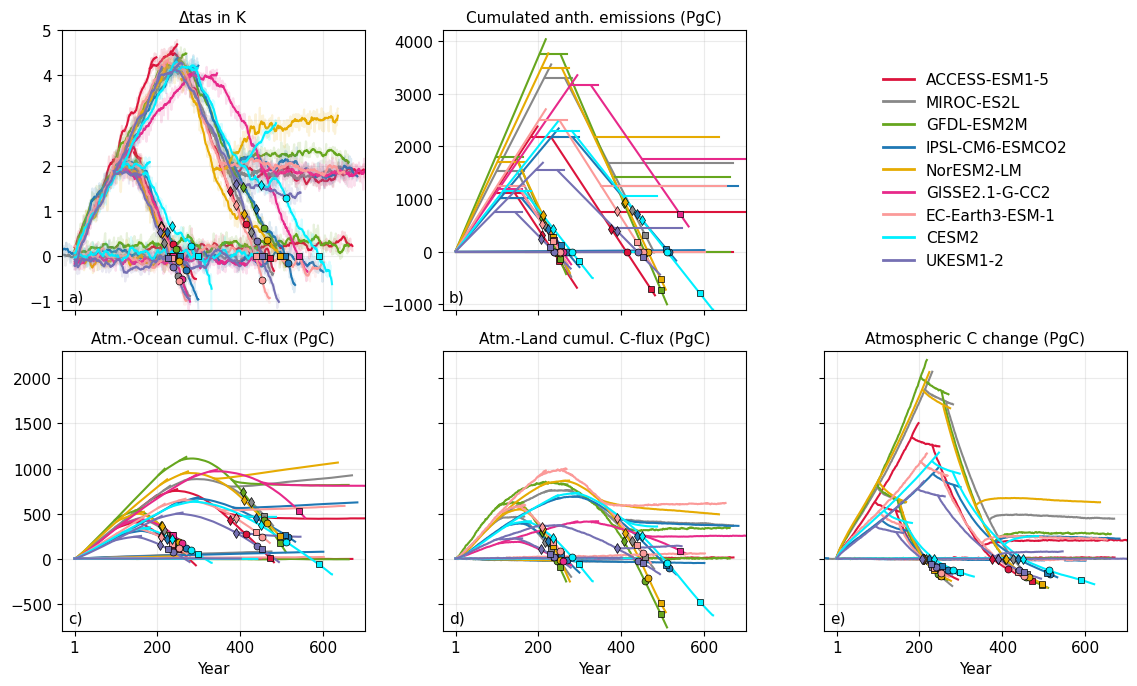

In [7]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 11

plt.rcParams['font.size']=11
fig,axa = plt.subplots(2,3,figsize=(11.5, 7),sharex=True)#,sharey='col')

axes = [axa[0,0],axa[0,1],axa[1,0],axa[1,1],axa[1,2]]
#gs = fig.add_gridspec(
#    2, 3,
#    #wspace=0.28,
#    #hspace=0.35,
#)

#ax1 = fig.add_subplot(gs[0, 0])              # tas
#ax2 = fig.add_subplot(gs[0, 1])              # fco2antt
ax_leg = axa[0,2] #fig.add_subplot(gs[0, 2])           # legend

#ax3 = fig.add_subplot(gs[1, 0])              # fgco2
#ax4 = fig.add_subplot(gs[1, 1], sharey=ax3)  # nbp
#ax5 = fig.add_subplot(gs[1, 2], sharey=ax3)  # co2mass

#axes = [ax1, ax2, ax3, ax4, ax5]

# put budget in 5th slot
plot_varias = [
    "tas",
    "fco2antt",
    "fgco2",
    "nbp",
    "co2mass",
]

# ============================================================
# formatting constants
# ============================================================

xlim = [
    cftime.DatetimeProlepticGregorian(-30, 1, 1),
    cftime.DatetimeProlepticGregorian(700, 1, 1),
]

xticks = [
    cftime.DatetimeProlepticGregorian(1, 1, 1),
    cftime.DatetimeProlepticGregorian(200, 1, 1),
    cftime.DatetimeProlepticGregorian(400, 1, 1),
    cftime.DatetimeProlepticGregorian(600, 1, 1),
]

# ============================================================
# legend handles
# ============================================================

legend_handles = {}

# ============================================================
# plotting
# ============================================================

for ax, varia in zip(axes, plot_varias):

    is_tas = varia == "tas"

    for model in models:

        freq_input = get_freq_input(model)
        stat = get_stat(varia, model) if varia != "budget" else "sum"

        #if model == 'GISSE2.1-G-CC2':
        #    member = MODELgrabber.get_grabber(model).get_member(run)
        #else:
        #    member = MODELgrabber.get_grabber(model).get_member()

        color = model_dict[model].color_id

        # clean legend handle once per model
        if model not in legend_handles:

            legend_handles[model] = Line2D(
                [0],
                [0],
                color=color,
                lw=2,
                alpha=1,
                label=model,
            )

        for run in runs:

            try:

                # synthetic budget panel
                if varia == "budget":

                    annual_stat = (
                        all_annual_stats["fgco2"][model][run]
                        + all_annual_stats["nbp"][model][run]
                        + all_annual_stats["co2mass"][model][run]
                    )

                else:

                    annual_stat = all_annual_stats[varia][model][run]


                # ------------------------------------------------
                # zero-crossing time from cumulative emissions
                # ------------------------------------------------
                
                emissions = all_annual_stats["fco2antt"][model][run]
                zero_time_emissions = first_zero_crossing(emissions)

                if model != 'GISSE2.1-G-CC2':
                    co2_mass = all_annual_stats["co2mass"][model][run]
                    zero_time_co2mass = first_zero_crossing(co2_mass)    

                #ref_temp = all_annual_stats["tas"][model]["esm-up2p0"].resample(time="YS").mean().isel(time=0)
                #print(all_annual_stats["tas"][model]["esm-up2p0"].resample(time="YS").mean())
                #annual_temp = all_annual_stats["tas"][model][run].resample(time="YS").mean() #- ref_temp #all_annual_stats["tas"][model][run].resample(time="YS").mean() - all_annual_stats["tas"][model]['esm-up2p0'].resample(time="YS").isel(year=0)
                #annual_temp_rm31 = all_annual_stats["tas"][model][run]#.rolling(time=31, center=True).mean()
                #zero_time_temp = first_zero_crossing(annual_temp_rm31)   
                annual_temp_rm31 = all_annual_stats["tas"][model][run].rolling(time=running_mean_years, center=True).mean()
                zero_time_temp = first_zero_crossing(annual_temp_rm31)   
                
                # raw series
                ax.plot(
                    annual_stat.time,
                    annual_stat,
                    alpha=0.15 if is_tas else 1,
                    color=color,
                )

                # smoothed tas overlay
                if is_tas:

                    smooth = annual_stat.rolling(
                        time=running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()

                    ax.plot(
                        smooth.time,
                        smooth,
                        alpha=1,
                        color=color,
                    )

            except Exception:

                print(
                    f"Nothing to plot for "
                    f"{varia}, {model}, {run}, "
                    f"{freq_input}, global {stat}."
                )
                zero_time_emissions = None
                zero_time_co2mass = None
                zero_time_temp = None


            # ------------------------------------------------
            # marker at net-zero year
            # ------------------------------------------------

            if run in ['esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0']:
                
                if zero_time_emissions is not None:
                
                    try:
                
                        marker_value = annual_stat.rolling(time=running_mean_years, center=True).mean().sel(time=zero_time_emissions)
                
                        ax.plot(
                            zero_time_emissions,
                            marker_value,
                            marker='o',
                            markersize=5,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
    
                if zero_time_co2mass is not None:
                
                    try:
                
                        marker_value = annual_stat.rolling(time=running_mean_years, center=True).mean().sel(time=zero_time_co2mass)
                
                        ax.plot(
                            zero_time_co2mass,
                            marker_value,
                            marker='d',
                            markersize=5,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
    
                if zero_time_temp is not None:
                
                    try:
                
                        #marker_value = annual_stat.sel(time=zero_time_temp)
                        marker_value = annual_stat.rolling(time=running_mean_years, center=True).mean().sel(time=zero_time_temp)

                        ax.plot(
                            zero_time_temp,
                            marker_value,
                            marker='s',
                            markersize=5,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
        
    # ========================================================
    # formatting
    # ========================================================

    tsize = 11

    if varia == "tas":
        ax.set_title(r"$\Delta$tas in K", fontsize=tsize)

    elif varia == "fgco2":
        ax.set_title("Atm.-Ocean cumul. C-flux (PgC)", fontsize=tsize)

    elif varia == "nbp":
        ax.set_title("Atm.-Land cumul. C-flux (PgC)", fontsize=tsize)

    elif varia == "co2mass":
        ax.set_title("Atmospheric C change (PgC)", fontsize=tsize)

    elif varia == "budget":
        ax.set_title(r"b)+c)+d)", fontsize=tsize)

    elif varia == "fco2antt":
        ax.set_title("Cumulated anth. emissions (PgC)", fontsize=tsize)

    ax.grid(alpha=0.25)

    ax.set_xlim(xlim)

    ax.set_xticks(xticks)
    ax.set_xticklabels([1, 200, 400, 600])

    # y limits
    if is_tas:
        ax.set_ylim([-1.2, 5])
    elif varia == 'fco2antt':
        ax.set_ylim([-1100, 4200])
    #else:
    #    ax.set_ylim([-1000, 4500])

    # suppress redundant y tick labels
    # left column keeps y labels
    if varia not in ["tas", "fgco2","fco2antt"]:
        ax.tick_params(labelleft=False)

for axi in axa[1,:]:
    axi.set_xlabel('Year')

for axi in axa[1,:]:
    axi.set_ylim([-800, 2300])

for ax, lab in zip(
    axes,
    ["a)", "b)", "c)", "d)", "e)"]
):
    ax.text(
        0.02, 0.02,
        lab,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
    )

# ============================================================
# legend
# ============================================================

ax_leg.axis("off")

ax_leg.legend(
    handles=list(legend_handles.values()),
    loc="center",
    frameon=False,
    ncols=1,
    #bbox_to_anchor=(0.01,0.01)
)
#plt.subplots_adjust(left=0.02,bottom=0.1)
#plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.savefig(f'./../03_plots/fundamental_time_series/carbon_changes_against_time.png',dpi=200,transparent=True)
plt.show()

## Now plot them individually

working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit


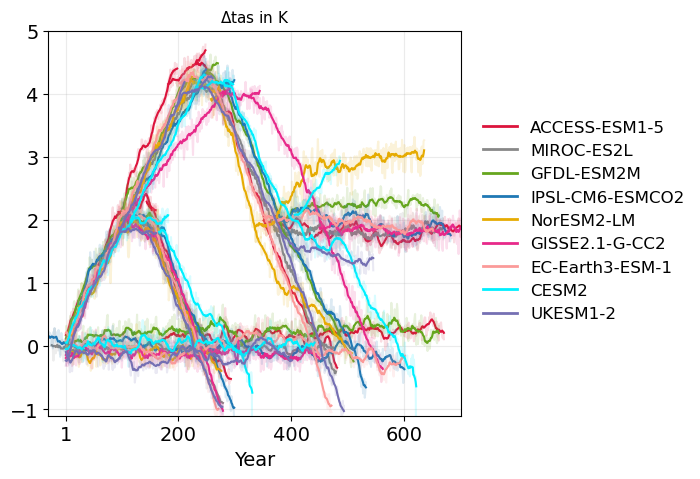

working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit


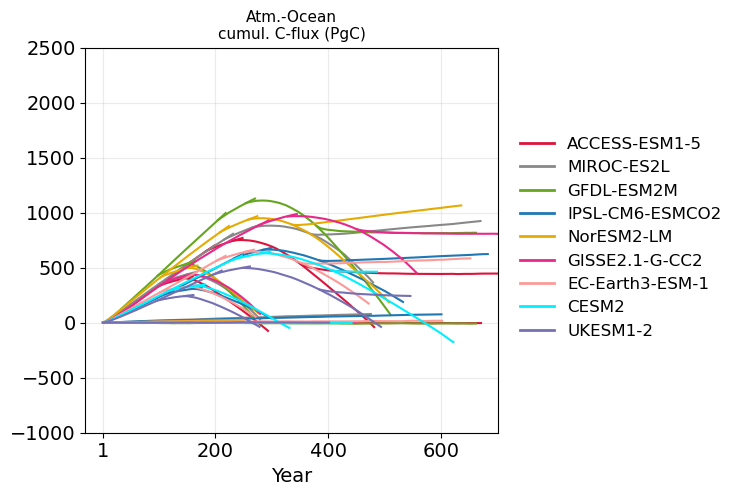

Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit


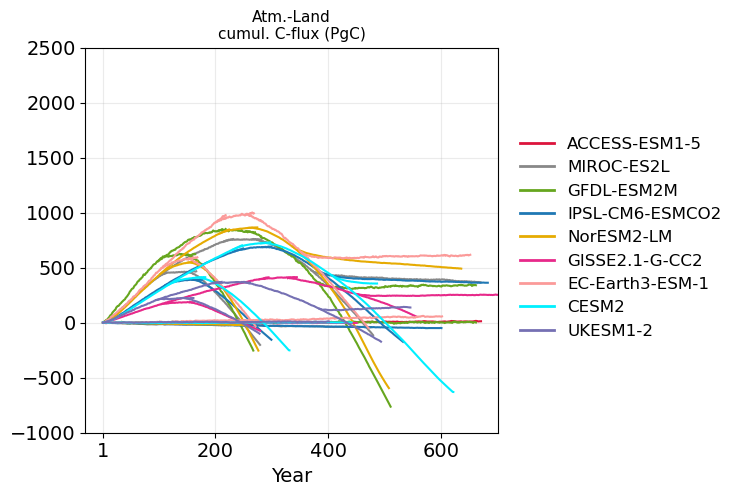

working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-piControl, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl4p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.


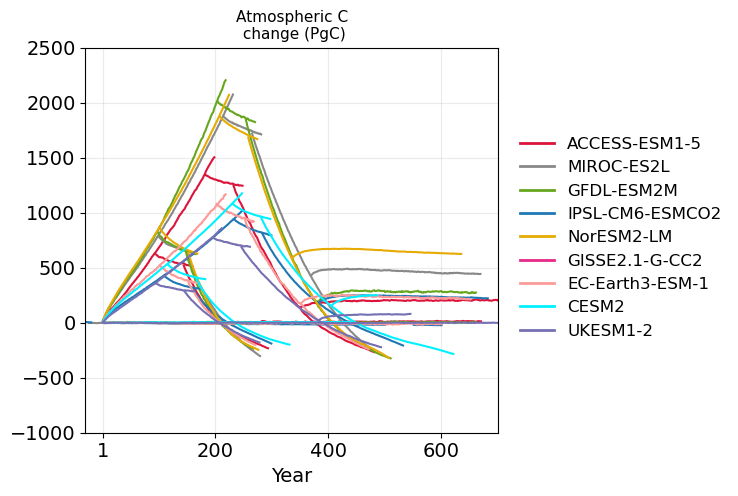

Nothing to plot for budget, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global sum.
Nothing to plot for budget, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global sum.
Nothing to plot for budget, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global sum.
Nothing to plot for budget, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global sum.
Nothing to plot for budget, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global sum.
Nothing to plot for budget, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global sum.
working on server spirit
Nothing to plot for budget, GISSE2.1-G-CC2, r1i1p1f3, esm-piControl, monthly, global sum.
working on server spirit
Nothing to plot for budget, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global sum.
working on server spirit
Nothing to plot for budget, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global sum.
working on server spirit
Nothing to plot for budget, GISSE2.1-G-CC2, r1i1p

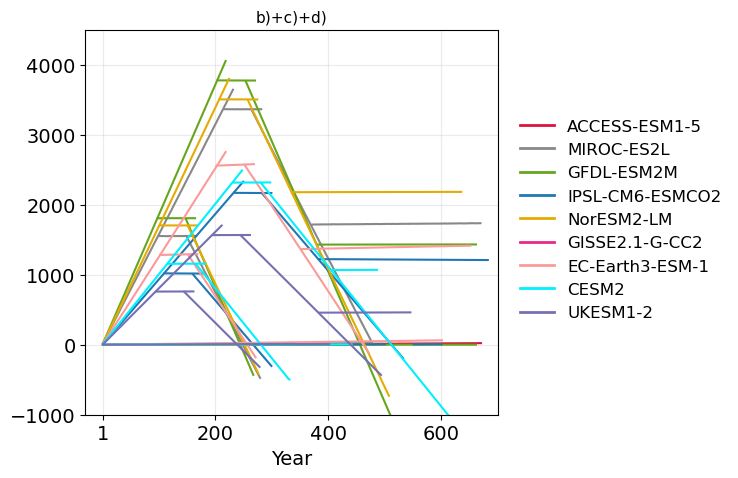

working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit
working on server spirit


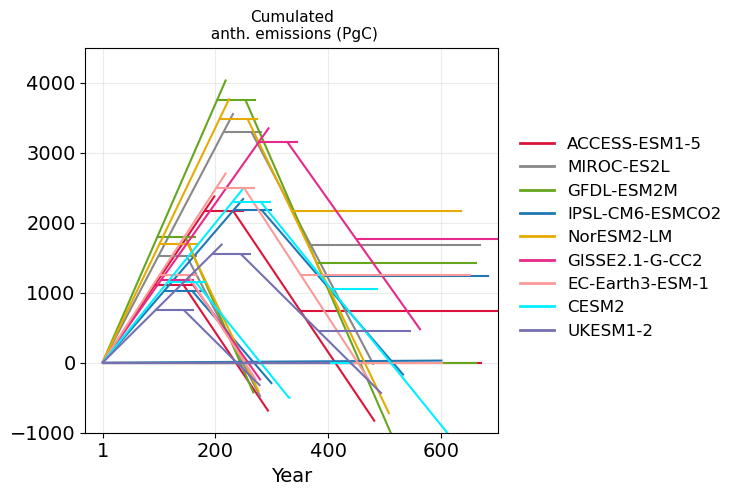

In [8]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 11

# put budget in 5th slot
plot_varias = [
    "tas",
    "fgco2",
    "nbp",
    "co2mass",
    "budget",
    "fco2antt",
]

which_letters_to_plot = []#['T']# ['T','E','C'] # ['T','E'] ['T','C'] ['E','C'] ['T'] ['E'] ['C']
scale_by_emissions = False
Erate_scale = 10 # PgC/yr

fontsize=14
plt.rcParams['font.size']=fontsize
for varia in plot_varias:
    fig, ax = plt.subplots(figsize=(7.5, 5))

    # ============================================================
    # formatting constants
    # ============================================================
    
    xlim = [
        cftime.DatetimeProlepticGregorian(-30, 1, 1),
        cftime.DatetimeProlepticGregorian(700, 1, 1),
    ]
    
    xticks = [
        cftime.DatetimeProlepticGregorian(1, 1, 1),
        cftime.DatetimeProlepticGregorian(200, 1, 1),
        cftime.DatetimeProlepticGregorian(400, 1, 1),
        cftime.DatetimeProlepticGregorian(600, 1, 1),
    ]
    
    # ============================================================
    # legend handles
    # ============================================================
    
    legend_handles = {}
    
    # ============================================================
    # plotting
    # ============================================================
        
    is_tas = varia == "tas"

    for model in models:

        freq_input = get_freq_input(model)
        stat = get_stat(varia, model) if varia != "budget" else "sum"

        #member = MODELgrabber.get_grabber(model).get_member()

        color = model_dict[model].color_id

        # clean legend handle once per model
        if model not in legend_handles:

            legend_handles[model] = Line2D(
                [0],
                [0],
                color=color,
                lw=2,
                alpha=1,
                label=model,
            )

        for run in runs:
            
            if model == 'GISSE2.1-G-CC2':
                member = MODELgrabber.get_grabber(model).get_member(run)
            else:
                member = MODELgrabber.get_grabber(model).get_member()

            try:

                # synthetic budget panel
                if varia == "budget":

                    annual_stat = (
                        all_annual_stats["fgco2"][model][run]
                        + all_annual_stats["nbp"][model][run]
                        + all_annual_stats["co2mass"][model][run]
                    )

                else:

                    annual_stat = all_annual_stats[varia][model][run]


                if scale_by_emissions == True and varia != 'tas':

                    Erate = model_dict[model].emission_rate
                    annual_stat = annual_stat / Erate * Erate_scale

                # ------------------------------------------------
                # zero-crossing time from cumulative emissions
                # ------------------------------------------------

                if 'E' in which_letters_to_plot:
                    emissions = all_annual_stats["fco2antt"][model][run]
                    zero_time_emissions = first_zero_crossing(emissions)

                if 'C' in which_letters_to_plot:
                    co2_mass = all_annual_stats["co2mass"][model][run]
                    zero_time_co2mass = first_zero_crossing(co2_mass)    

                #ref_temp = all_annual_stats["tas"][model]["esm-up2p0"].resample(time="YS").mean().isel(time=0)
                #print(all_annual_stats["tas"][model]["esm-up2p0"].resample(time="YS").mean())
                #annual_temp = all_annual_stats["tas"][model][run].resample(time="YS").mean() #- ref_temp #all_annual_stats["tas"][model][run].resample(time="YS").mean() - all_annual_stats["tas"][model]['esm-up2p0'].resample(time="YS").isel(year=0)
                if 'T' in which_letters_to_plot:
                    annual_temp_rm31 = all_annual_stats["tas"][model][run].rolling(time=running_mean_years, center=True).mean()
                    zero_time_temp = first_zero_crossing(annual_temp_rm31)   
                
                # raw series
                ax.plot(
                    annual_stat.time,
                    annual_stat,
                    alpha=0.15 if is_tas else 1,
                    color=color,
                )

                # smoothed tas overlay
                if is_tas:

                    smooth = annual_stat.rolling(
                        time=running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()

                    ax.plot(
                        smooth.time,
                        smooth,
                        alpha=1,
                        color=color,
                    )

            except Exception:

                print(
                    f"Nothing to plot for "
                    f"{varia}, {model}, {member}, {run}, "
                    f"{freq_input}, global {stat}."
                )


            # ------------------------------------------------
            # marker at net-zero year
            # ------------------------------------------------

            if run in ['esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0']:

                if 'E' in which_letters_to_plot and zero_time_emissions is not None:
                
                    try:
                
                        marker_value = annual_stat.rolling(time=running_mean_years, center=True).mean().sel(time=zero_time_emissions)
                
                        ax.plot(
                            zero_time_emissions,
                            marker_value,
                            marker='$\mathbf{E}$',
                            markersize=10,
                            color=color,
                            markeredgecolor='k',
                            linewidth=5,
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
    
                if 'C' in which_letters_to_plot and zero_time_co2mass is not None:

                    try:
                
                        marker_value = annual_stat.rolling(time=running_mean_years, center=True).mean().sel(time=zero_time_co2mass)
                
                        ax.plot(
                            zero_time_co2mass,
                            marker_value,
                            marker='$\mathbf{C}$',
                            markersize=10,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
    
                if 'T' in which_letters_to_plot and zero_time_temp is not None:

                    try:
                
                        marker_value = annual_stat.rolling(time=running_mean_years, center=True).mean().sel(time=zero_time_temp)
                
                        ax.plot(
                            zero_time_temp,
                            marker_value,
                            marker='$\mathbf{T}$',
                            markersize=10,
                            color=color,
                            markeredgecolor='k',
                            markeredgewidth=0.5,
                            zorder=10,
                        )
                
                    except Exception:
                        pass
        
    # ========================================================
    # formatting
    # ========================================================

    tsize = 11

    if varia == "tas":
        ax.set_title(r"$\Delta$tas in K", fontsize=tsize)

    elif varia == "fgco2":
        ax.set_title("Atm.-Ocean\ncumul. C-flux (PgC)", fontsize=tsize)

    elif varia == "nbp":
        ax.set_title("Atm.-Land\ncumul. C-flux (PgC)", fontsize=tsize)

    elif varia == "co2mass":
        ax.set_title("Atmospheric C\n change (PgC)", fontsize=tsize)

    elif varia == "budget":
        ax.set_title(r"b)+c)+d)", fontsize=tsize)

    elif varia == "fco2antt":
        ax.set_title("Cumulated\n anth. emissions (PgC)", fontsize=tsize)

    ax.grid(alpha=0.25)

    ax.set_xlim(xlim)

    ax.set_xticks(xticks)
    ax.set_xticklabels([1, 200, 400, 600])

    # y limits
    if is_tas:
        ax.set_ylim([-1.1, 5])

    elif varia in ['budget','fco2antt']:
        ax.set_ylim([-1000, 4500])
    else:
        ax.set_ylim([-1000, 2500])

    # suppress redundant y tick labels
    #if varia not in ["fgco2", "tas"]:
    #    ax.tick_params(labelleft=False)
    
    #for axi in axes:
    ax.set_xlabel('Year')
    
    #for axi,lab in zip(axes,['a)','b)','c)','d)','e)','f)']):
    #ax.text(0.02,0.02,lab,ha='left',va='bottom',transform=axi.transAxes)
    
    # ============================================================
    # legend
    # ============================================================
    
    fig.legend(
        handles=list(legend_handles.values()),
        loc="center left",
        bbox_to_anchor=(0.71, 0.5),
        frameon=False,
        fontsize=fontsize-2
    )
    
    plt.subplots_adjust(left=0.15,right=0.7)
    #plt.subplots_adjust(bottom=0.15)
    if scale_by_emissions == True:   
        #print('would plot')
        plt.savefig(f'./../03_plots/fundamental_time_series/timeseries_{varia}_ESCALED{Erate_scale}_with_letters_{"".join(which_letters_to_plot)}.png',dpi=200,transparent=True)
    else:
        plt.savefig(f'./../03_plots/fundamental_time_series/timeseries_{varia}_with_letters_{"".join(which_letters_to_plot)}.png',dpi=200,transparent=True)
    plt.show()

## Plot the cumulated carbon fluxes and the atmospheric carbon against tas

working on server spirit
working on server spirit
working on server spirit
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.


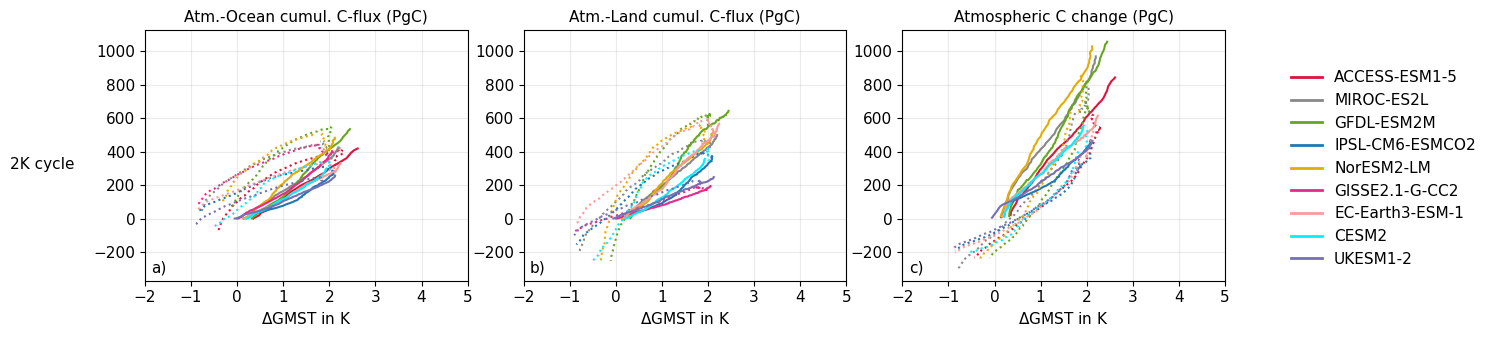

working on server spirit
working on server spirit
working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl4p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, mont

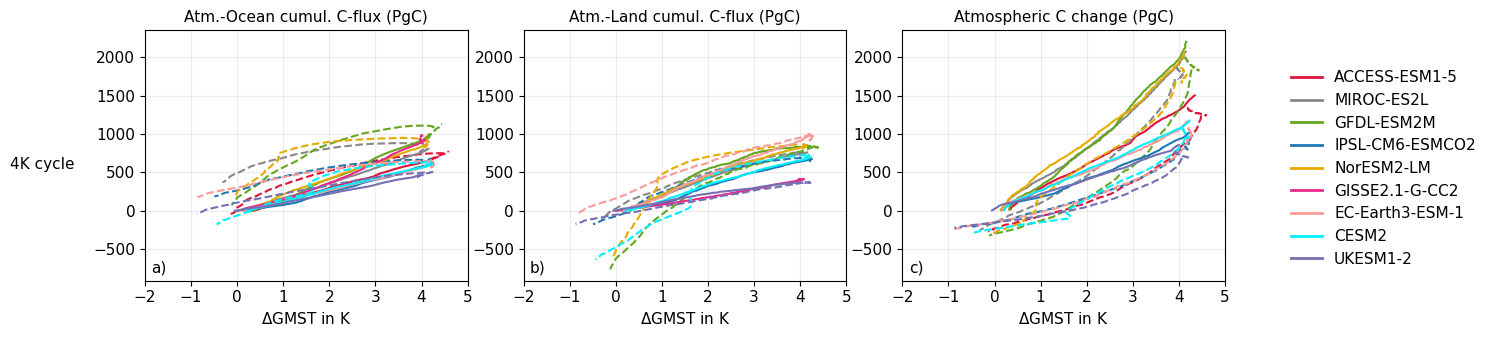

In [13]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 31

run_cycles = dict()
run_cycles['2K'] = ['esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl2p0-50y-dn2p0']
run_cycles['4K'] = ['esm-up2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl4p0-50y-dn2p0']

plt.rcParams['font.size']=11


for run_cycle in run_cycles.keys():
    
    fig = plt.figure(figsize=(15, 3.5))
    figtext_written = 0

    # ============================================================
    # layout
    # ============================================================
    
    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=[1, 1, 1],
        #wspace=0.08,
    )
    
    # shared-y group
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)
    
    axes = [ax0, ax1, ax2]
    
    # define variables to plot
    plot_varias = [
        "fgco2",
        "nbp",
        "co2mass",
    ]
    
    # ============================================================
    # formatting constants
    # ============================================================
    
    xlim = [-2,5]
    xticks = [-2,-1,0,1,2,3,4,5]
    
    # ============================================================
    # legend handles
    # ============================================================
    
    legend_handles = {}
    
    # ============================================================
    # plotting
    # ============================================================
    
    for ax, varia in zip(axes, plot_varias):
    
        for model in models:
    
            freq_input = get_freq_input(model)
            stat = get_stat(varia, model) #if varia != "budget" else "sum"
    
            color = model_dict[model].color_id
    
            # clean legend handle once per model
            if model not in legend_handles:
    
                legend_handles[model] = Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    alpha=1,
                    label=model,
                )
    
            for run in run_cycles[run_cycle]:

                if model == 'GISSE2.1-G-CC2':
                    member = MODELgrabber.get_grabber(model).get_member(run)
                else:
                    member = MODELgrabber.get_grabber(model).get_member()
                
                figtext = f'{run_cycle} cycle'
                    
                if figtext_written == 0:
                    fig.text(0.01,0.5,figtext)
                    figtext_written += 1

                try:
    
                    # synthetic budget panel
                    #if varia == "budget":
                    #
                    #    annual_stat = (
                    #        all_annual_stats["fgco2"][model][run]
                    #        + all_annual_stats["nbp"][model][run]
                    #        + all_annual_stats["co2mass"][model][run]
                    #    )
                    #
                    #else:
                    #
                    annual_stat = all_annual_stats[varia][model][run]       # /  model_dict[model].emission_rate
                    annual_stat_tas = all_annual_stats['tas'][model][run]  

                    if run == 'esm-up2p0' and run_cycle == '2K':
                        annual_stat = annual_stat.isel(time=slice(None,120))
                        annual_stat_tas = annual_stat_tas.isel(time=slice(None,120))

    
                    # ------------------------------------------------
                    # zero-crossing time from cumulative emissions
                    # ------------------------------------------------
                    
                    #emissions = all_annual_stats["fco2antt"][model][run]
                    
                    #zero_time = first_zero_crossing(emissions)
    
                    
                    # raw series
                    #ax.plot(
                    #    annual_stat_tas,
                    #    annual_stat,
                    #    alpha=0.15,# if is_tas else 1,
                    #    color=color,
                    #)
    
                    # smoothed tas overlay
                    smooth_tas = annual_stat_tas.rolling(
                        time=running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
                    
                    smooth = annual_stat.rolling(
                        time=1,#running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
    
                    ax.plot(
                        smooth_tas,
                        smooth,
                        alpha=1,
                        color=color,
                        linestyle=run_dict[run].linestyle_id
                    )
    
                except Exception:
    
                    print(
                        f"Nothing to plot for "
                        f"{varia}, {model}, {member}, {run}, "
                        f"{freq_input}, global {stat}."
                    )
    
                # ------------------------------------------------
                # marker at net-zero year
                # ------------------------------------------------
                
                #if zero_time is not None:
                # 
                #    try:
                #
                #        marker_value = annual_stat.sel(time=zero_time)
                #
                #        ax.plot(
                #            zero_time,
                #            marker_value,
                #            marker='o',
                #            markersize=5,
                #            color=color,
                #            markeredgecolor='k',
                #            markeredgewidth=0.5,
                #            zorder=10,
                #        )
                # 
                #    except Exception:
                #        pass
        
        # ========================================================
        # formatting
        # ========================================================
    
        tsize = 11
    
        if varia == "tas":
            ax.set_title(r"$\Delta$tas in K", fontsize=tsize)
    
        elif varia == "fgco2":
            ax.set_title("Atm.-Ocean cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "nbp":
            ax.set_title("Atm.-Land cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "co2mass":
            ax.set_title("Atmospheric C change (PgC)", fontsize=tsize)
    
        elif varia == "budget":
            ax.set_title(r"b)+c)+d)", fontsize=tsize)
    
        elif varia == "fco2antt":
            ax.set_title("Cumulated\n anth. emissions (PgC)", fontsize=tsize)
    
        ax.grid(alpha=0.25)
    
        ax.set_xlim(xlim)
    
        #ax.set_xticks(xticks)
        #ax.set_xticklabels([1, 200, 400, 600])
    
        # y limits
        #if is_tas:
        #    ax.set_ylim([-1.1, 5])
    
        #else:
        #    ax.set_ylim([-1000, 2500])
    
        # suppress redundant y tick labels
        #if varia not in ["fgco2", "tas"]:
        #    ax.tick_params(labelleft=False)
    
    for axi in axes:
        axi.set_xlabel(r'$\Delta$GMST in K')
    
    for axi,lab in zip(axes,['a)','b)','c)','d)','e)','f)']):
        axi.text(0.02,0.02,lab,ha='left',va='bottom',transform=axi.transAxes)
    
    # ============================================================
    # legend
    # ============================================================
    
    fig.legend(
        handles=list(legend_handles.values()),
        loc="center left",
        bbox_to_anchor=(0.855, 0.5),
        frameon=False,
    )
    
    #plt.subplots_adjust(left=0.02,bottom=0.1)
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.82)
    plt.savefig(f'./../03_plots/fundamental_time_series/carbon_changes_against_gmst_{run_cycle}cycle.png',dpi=200,transparent=True)
    plt.show()

## Now plot the cumulated air-sea and air-land carbon fluxes as a function of atmospheric C changes

working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global integral.
working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global integral.
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0-50y-dn2p0, monthly, 

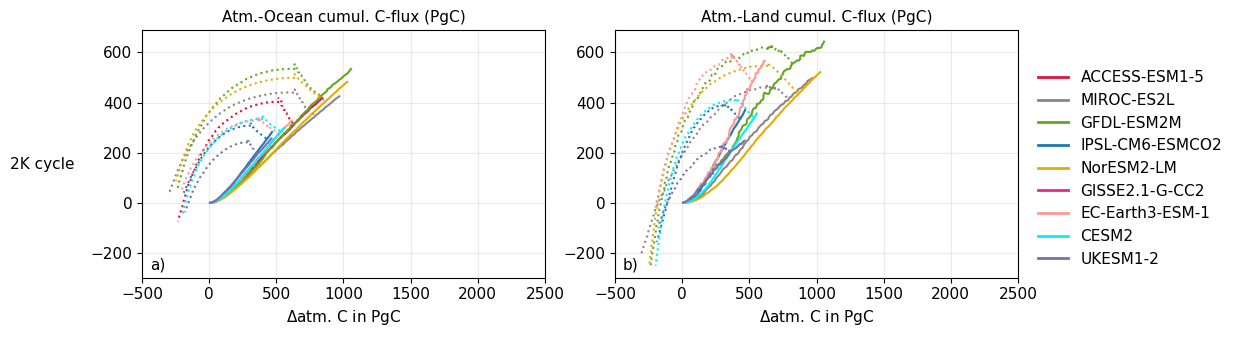

working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl4p0, monthly, global integral.
working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl4p0, monthly, global integral.
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, 

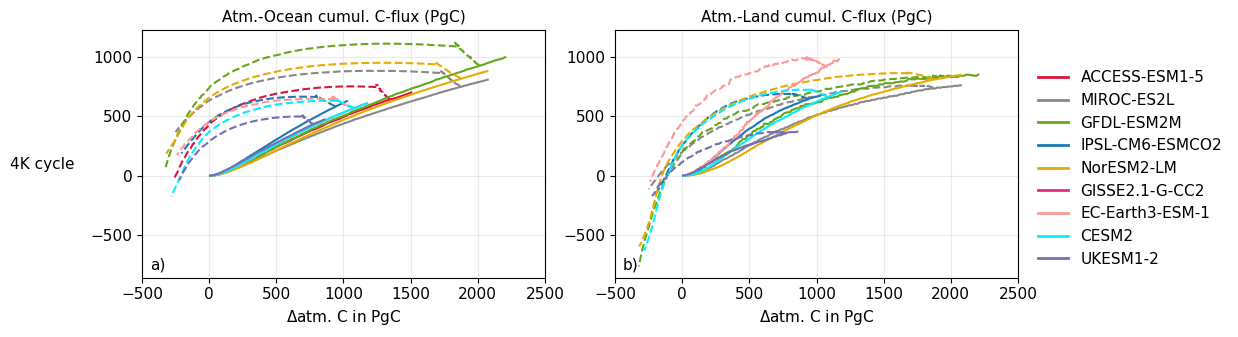

In [14]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 1

run_cycles = dict()
run_cycles['2K'] = ['esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl2p0-50y-dn2p0']
run_cycles['4K'] = ['esm-up2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl4p0-50y-dn2p0']

plt.rcParams['font.size']=11


for run_cycle in run_cycles.keys():
    
    fig = plt.figure(figsize=(12, 3.5))
    figtext_written = 0

    # ============================================================
    # layout
    # ============================================================
    
    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[1, 1],
        #wspace=0.08,
    )
    
    # shared-y group
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    
    axes = [ax0, ax1]
    
    # define variables to plot
    plot_varias = [
        "fgco2",
        "nbp",
    ]
    
    # ============================================================
    # formatting constants
    # ============================================================
    
    xlim = [-500,2500]
    xticks = [-500,0,500,1000,1500,2000,2500]
    
    # ============================================================
    # legend handles
    # ============================================================
    
    legend_handles = {}
    
    # ============================================================
    # plotting
    # ============================================================
    
    for ax, varia in zip(axes, plot_varias):
    
        for model in models:
    
            freq_input = get_freq_input(model)
            stat = get_stat(varia, model) #if varia != "budget" else "sum"
    
            #member = MODELgrabber.get_grabber(model).get_member()
    
            color = model_dict[model].color_id
    
            # clean legend handle once per model
            if model not in legend_handles:
    
                legend_handles[model] = Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    alpha=1,
                    label=model,
                )
    
            for run in run_cycles[run_cycle]:

                if model == 'GISSE2.1-G-CC2':
                    member = MODELgrabber.get_grabber(model).get_member(run)
                else:
                    member = MODELgrabber.get_grabber(model).get_member()                
                
                figtext = f'{run_cycle} cycle'
                    
                if figtext_written == 0:
                    fig.text(0.01,0.5,figtext)
                    figtext_written += 1

                try:
    
                    # synthetic budget panel
                    #if varia == "budget":
                    #
                    #    annual_stat = (
                    #        all_annual_stats["fgco2"][model][run]
                    #        + all_annual_stats["nbp"][model][run]
                    #        + all_annual_stats["co2mass"][model][run]
                    #    )
                    #
                    #else:
                    #
                    annual_stat = all_annual_stats[varia][model][run]       # /  model_dict[model].emission_rate
                    annual_stat_co2 = all_annual_stats['co2mass'][model][run]  

                    if run == 'esm-up2p0' and run_cycle == '2K':
                        annual_stat = annual_stat.isel(time=slice(None,120))
                        annual_stat_co2 = annual_stat_co2.isel(time=slice(None,120))

    
                    # ------------------------------------------------
                    # zero-crossing time from cumulative emissions
                    # ------------------------------------------------
                    
                    #emissions = all_annual_stats["fco2antt"][model][run]
                    
                    #zero_time = first_zero_crossing(emissions)
    
                    
                    # raw series
                    #ax.plot(
                    #    annual_stat_tas,
                    #    annual_stat,
                    #    alpha=0.15,# if is_tas else 1,
                    #    color=color,
                    #)
    
                    # smoothed tas overlay
                    smooth_co2 = annual_stat_co2.rolling(
                        time=running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
                    
                    smooth = annual_stat.rolling(
                        time=1,#running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
    
                    ax.plot(
                        smooth_co2,
                        smooth,
                        alpha=1,
                        color=color,
                        linestyle=run_dict[run].linestyle_id
                    )
    
                except Exception:
    
                    print(
                        f"Nothing to plot for "
                        f"{varia}, {model}, {member}, {run}, "
                        f"{freq_input}, global {stat}."
                    )
    
                # ------------------------------------------------
                # marker at net-zero year
                # ------------------------------------------------
                
                #if zero_time is not None:
                #
                #    try:
                #
                #        marker_value = annual_stat.sel(time=zero_time)
                #
                #        ax.plot(
                #            zero_time,
                #            marker_value,
                #            marker='o',
                #            markersize=5,
                #            color=color,
                #            markeredgecolor='k',
                #            markeredgewidth=0.5,
                #            zorder=10,
                #        )
                #
                #    except Exception:
                #        pass
        
        # ========================================================
        # formatting
        # ========================================================
    
        tsize = 11
    
        if varia == "tas":
            ax.set_title(r"$\Delta$tas in K", fontsize=tsize)
    
        elif varia == "fgco2":
            ax.set_title("Atm.-Ocean cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "nbp":
            ax.set_title("Atm.-Land cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "co2mass":
            ax.set_title("Atmospheric C change (PgC)", fontsize=tsize)
    
        elif varia == "budget":
            ax.set_title(r"b)+c)+d)", fontsize=tsize)
    
        elif varia == "fco2antt":
            ax.set_title("Cumulated\n anth. emissions (PgC)", fontsize=tsize)
    
        ax.grid(alpha=0.25)
    
        ax.set_xlim(xlim)
    
        #ax.set_xticks(xticks)
        #ax.set_xticklabels([1, 200, 400, 600])
    
        # y limits
        #if is_tas:
        #    ax.set_ylim([-1.1, 5])
    
        #else:
        #    ax.set_ylim([-1000, 2500])
    
        # suppress redundant y tick labels
        #if varia not in ["fgco2", "tas"]:
        #    ax.tick_params(labelleft=False)
    
    for axi in axes:
        axi.set_xlabel(r'$\Delta$atm. C in PgC')
    
    for axi,lab in zip(axes,['a)','b)','c)','d)','e)','f)']):
        axi.text(0.02,0.02,lab,ha='left',va='bottom',transform=axi.transAxes)
    
    # ============================================================
    # legend
    # ============================================================
    
    fig.legend(
        handles=list(legend_handles.values()),
        loc="center left",
        bbox_to_anchor=(0.855, 0.5),
        frameon=False,
    )
    
    #plt.subplots_adjust(left=0.02,bottom=0.1)
    plt.tight_layout()
    plt.subplots_adjust(left=0.12,right=0.85)
    plt.savefig(f'./../03_plots/fundamental_time_series/carbon_changes_against_atmC_{run_cycle}cycle.png',dpi=200,transparent=True)
    plt.show()

## Now plot the fluxes against cumulative emissions

working on server spirit
working on server spirit
working on server spirit
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.


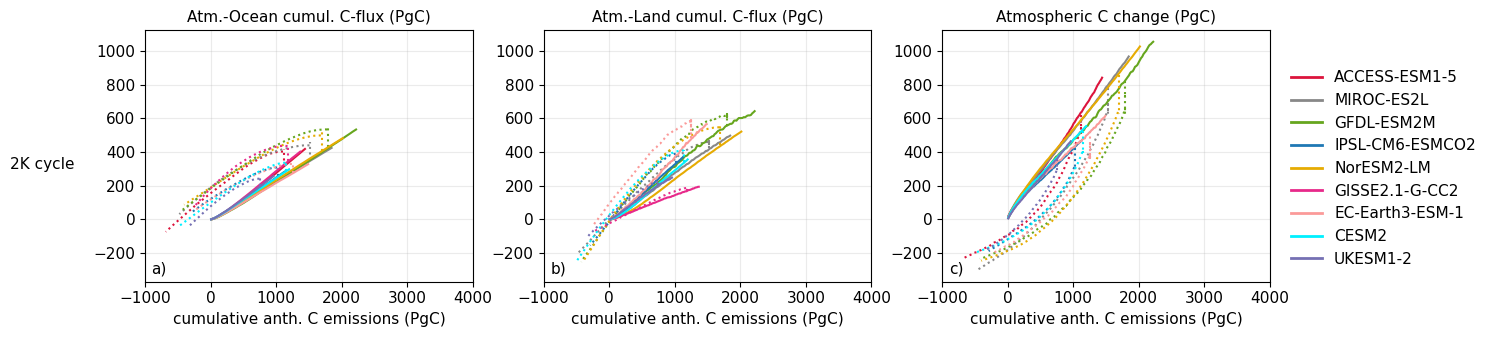

working on server spirit
working on server spirit
working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
Nothing to plot for nbp, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl4p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, mont

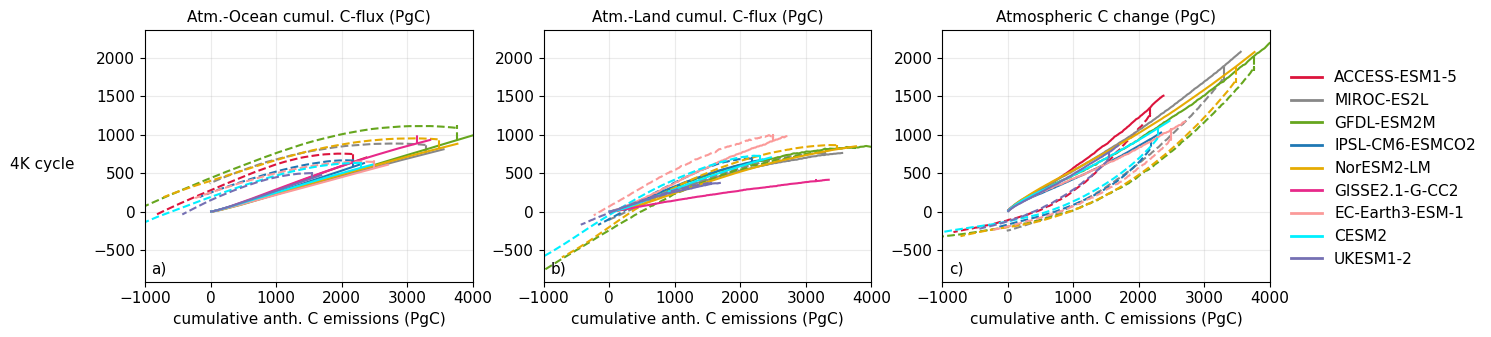

In [15]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 1

run_cycles = dict()
run_cycles['2K'] = ['esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl2p0-50y-dn2p0']
run_cycles['4K'] = ['esm-up2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl4p0-50y-dn2p0']

plt.rcParams['font.size']=11


for run_cycle in run_cycles.keys():
    
    fig = plt.figure(figsize=(15, 3.5))
    figtext_written = 0

    # ============================================================
    # layout
    # ============================================================
    
    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=[1, 1, 1],
        #wspace=0.08,
    )
    
    # shared-y group
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)
    
    axes = [ax0, ax1, ax2]
    
    # define variables to plot
    plot_varias = [
        "fgco2",
        "nbp",
        "co2mass",
    ]
    
    # ============================================================
    # formatting constants
    # ============================================================
    
    xlim = [-1000,4000]
    xticks = [-1000,0,1000,2000,3000,4000]
    
    # ============================================================
    # legend handles
    # ============================================================
    
    legend_handles = {}
    
    # ============================================================
    # plotting
    # ============================================================
    
    for ax, varia in zip(axes, plot_varias):
    
        for model in models:
    
            freq_input = get_freq_input(model)
            stat = get_stat(varia, model) #if varia != "budget" else "sum"
    
            #member = MODELgrabber.get_grabber(model).get_member()
    
            color = model_dict[model].color_id
    
            # clean legend handle once per model
            if model not in legend_handles:
    
                legend_handles[model] = Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    alpha=1,
                    label=model,
                )
    
            for run in run_cycles[run_cycle]:

                if model == 'GISSE2.1-G-CC2':
                    member = MODELgrabber.get_grabber(model).get_member(run)
                else:
                    member = MODELgrabber.get_grabber(model).get_member()                
                
                figtext = f'{run_cycle} cycle'
                    
                if figtext_written == 0:
                    fig.text(0.01,0.5,figtext)
                    figtext_written += 1

                try:
    
                    annual_stat = all_annual_stats[varia][model][run]       # /  model_dict[model].emission_rate
                    annual_stat_emissions = all_annual_stats["fco2antt"][model][run] 
    
                    if run == 'esm-up2p0' and run_cycle == '2K':
                        annual_stat = annual_stat.isel(time=slice(None,120))
                        annual_stat_emissions = annual_stat_emissions.isel(time=slice(None,120))
    
    
                    # ------------------------------------------------
                    # zero-crossing time from cumulative emissions
                    # ------------------------------------------------
                    
                    #emissions = all_annual_stats["fco2antt"][model][run]
                    
                    #zero_time = first_zero_crossing(emissions)
    
                    
                    # raw series
                    #ax.plot(
                    #    annual_stat_tas,
                    #    annual_stat,
                    #    alpha=0.15,# if is_tas else 1,
                    #    color=color,
                    #)
    
                    # smoothed tas overlay
                    smooth_emissions = annual_stat_emissions.rolling(
                        time=1,#running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
                                            
                    smooth = annual_stat.rolling(
                        time=1,#running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
    
                    ax.plot(
                        smooth_emissions,
                        smooth,
                        alpha=1,
                        color=color,
                        linestyle=run_dict[run].linestyle_id
                    )
    
                except Exception:
                
                    print(
                        f"Nothing to plot for "
                        f"{varia}, {model}, {member}, {run}, "
                        f"{freq_input}, global {stat}."
                    )
    
                # ------------------------------------------------
                # marker at net-zero year
                # ------------------------------------------------
                
                #if zero_time is not None:
                # 
                #    try:
                #
                #        marker_value = annual_stat.sel(time=zero_time)
                #
                #        ax.plot(
                #            zero_time,
                #            marker_value,
                #            marker='o',
                #            markersize=5,
                #            color=color,
                #            markeredgecolor='k',
                #            markeredgewidth=0.5,
                #            zorder=10,
                #        )
                #
                #    except Exception:
                #        pass
        
        # ========================================================
        # formatting
        # ========================================================
    
        tsize = 11
    
        if varia == "tas":
            ax.set_title(r"$\Delta$tas in K", fontsize=tsize)
    
        elif varia == "fgco2":
            ax.set_title("Atm.-Ocean cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "nbp":
            ax.set_title("Atm.-Land cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "co2mass":
            ax.set_title("Atmospheric C change (PgC)", fontsize=tsize)
    
        elif varia == "budget":
            ax.set_title(r"b)+c)+d)", fontsize=tsize)
    
        elif varia == "fco2antt":
            ax.set_title("Cumulated\n anth. emissions (PgC)", fontsize=tsize)
    
        ax.grid(alpha=0.25)
    
        ax.set_xlim(xlim)
    
        #ax.set_xticks(xticks)
        #ax.set_xticklabels([1, 200, 400, 600])
    
        # y limits
        #if is_tas:
        #    ax.set_ylim([-1.1, 5])
    
        #else:
        #    ax.set_ylim([-1000, 2500])
    
        # suppress redundant y tick labels
        #if varia not in ["fgco2", "tas"]:
        #    ax.tick_params(labelleft=False)
    
    for axi in axes:
        axi.set_xlabel(r'cumulative anth. C emissions (PgC)')
    
    for axi,lab in zip(axes,['a)','b)','c)','d)','e)','f)']):
        axi.text(0.02,0.02,lab,ha='left',va='bottom',transform=axi.transAxes)
    
    # ============================================================
    # legend
    # ============================================================
    
    fig.legend(
        handles=list(legend_handles.values()),
        loc="center left",
        bbox_to_anchor=(0.855, 0.5),
        frameon=False,
    )
    
    #plt.subplots_adjust(left=0.02,bottom=0.1)
    plt.tight_layout()
    plt.subplots_adjust(left=0.1,right=0.85)
    #plt.savefig(f'./../03_plots/fundamental_time_series/carbon_changes_against_emissions_{run_cycle}cycle.png',dpi=200,transparent=True)
    plt.show()

## Now in one figure

working on server spirit
working on server spirit
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0, monthly, global integral.
working on server spirit
Nothing to plot for co2mass, GISSE2.1-G-CC2, r1i1p1f3, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
working on server spirit
working on server spirit
working on server spirit
Nothing to plot for fgco2, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, mon

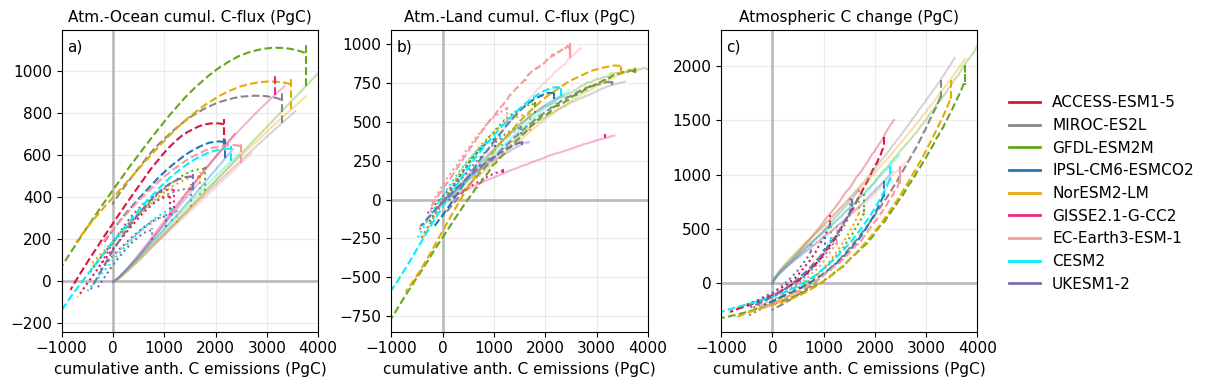

In [17]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 1

run_cycles = dict()
run_cycles['2K'] = ['esm-up2p0-gwl2p0','esm-up2p0-gwl2p0-50y-dn2p0']
run_cycles['4K'] = ['esm-up2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl4p0-50y-dn2p0']

plt.rcParams['font.size']=11


    
fig, ax = plt.subplots(1,3,figsize=(12, 4))#,sharey=True)

figtext_written = 0

# ============================================================
# layout
# ============================================================

axes = [ax[0], ax[1], ax[2]]

# define variables to plot
plot_varias = [
    "fgco2",
    "nbp",
    "co2mass",
]

# ============================================================
# formatting constants
# ============================================================

xlim = [-1000,4000]
xticks = [-1000,0,1000,2000,3000,4000]

for run_cycle in run_cycles.keys():

    # ============================================================
    # legend handles
    # ============================================================
    
    legend_handles = {}
    
    # ============================================================
    # plotting
    # ============================================================
    
    for ax, varia in zip(axes, plot_varias):
    
        for model in models:
    
            freq_input = get_freq_input(model)
            stat = get_stat(varia, model) #if varia != "budget" else "sum"
    
            #member = MODELgrabber.get_grabber(model).get_member()
    
            color = model_dict[model].color_id
    
            # clean legend handle once per model
            if model not in legend_handles:
    
                legend_handles[model] = Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    alpha=1,
                    label=model,
                )
    
            for run in run_cycles[run_cycle]:

                if model == 'GISSE2.1-G-CC2':
                    member = MODELgrabber.get_grabber(model).get_member(run)
                else:
                    member = MODELgrabber.get_grabber(model).get_member()         
                    
                try:
    
                    annual_stat = all_annual_stats[varia][model][run]       # /  model_dict[model].emission_rate
                    annual_stat_emissions = all_annual_stats["fco2antt"][model][run]  

                    if run == 'esm-up2p0' and run_cycle == '2K':
                        annual_stat = annual_stat.isel(time=slice(None,120))
                        annual_stat_emissions = annual_stat_emissions.isel(time=slice(None,120))
    
                    # smoothed tas overlay
                    smooth_emissions = annual_stat_emissions.rolling(
                        time=running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()
                    
                    smooth = annual_stat.rolling(
                        time=1,#running_mean_years,
                        center=True,
                        min_periods=1,
                    ).mean()

                    if run == 'esm-up2p0':
                        alpha=0.35
                    else:
                        alpha = 1
                    ax.plot(
                        smooth_emissions,
                        smooth,
                        alpha=alpha,
                        color=color,
                        linestyle=run_dict[run].linestyle_id
                    )
    
                except Exception:
    
                    print(
                        f"Nothing to plot for "
                        f"{varia}, {model}, {member}, {run}, "
                        f"{freq_input}, global {stat}."
                    )
        
        # ========================================================
        # formatting
        # ========================================================
    
        tsize = 11
    
        if varia == "tas":
            ax.set_title(r"$\Delta$tas in K", fontsize=tsize)
    
        elif varia == "fgco2":
            ax.set_title("Atm.-Ocean cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "nbp":
            ax.set_title("Atm.-Land cumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "co2mass":
            ax.set_title("Atmospheric C change (PgC)", fontsize=tsize)
    
        elif varia == "budget":
            ax.set_title(r"b)+c)+d)", fontsize=tsize)
    
        elif varia == "fco2antt":
            ax.set_title("Cumulated\n anth. emissions (PgC)", fontsize=tsize)
    
        ax.grid(alpha=0.25)
    
        ax.set_xlim(xlim)
    
    for axi in axes:
        axi.set_xlabel(r'cumulative anth. C emissions (PgC)')
    
for axi,lab in zip(axes,['a)','b)','c)','d)','e)','f)']):
    axi.text(0.02,0.97,lab,ha='left',va='top',transform=axi.transAxes)
    axi.axhline(0,color='k',zorder=-10,alpha=0.25,linewidth=2)
    axi.axvline(0,color='k',zorder=-10,alpha=0.25,linewidth=2)

# ============================================================
# legend
# ============================================================

fig.legend(
    handles=list(legend_handles.values()),
    loc="center left",
    bbox_to_anchor=(0.835, 0.5),
    frameon=False,
)

plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.savefig(f'./../03_plots/fundamental_time_series/carbon_changes_against_emissions_2K_and_4K_cycle.png',dpi=200,transparent=True)
plt.show()

Nothing to plot for tas, NorESM2-LM, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global mean.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.


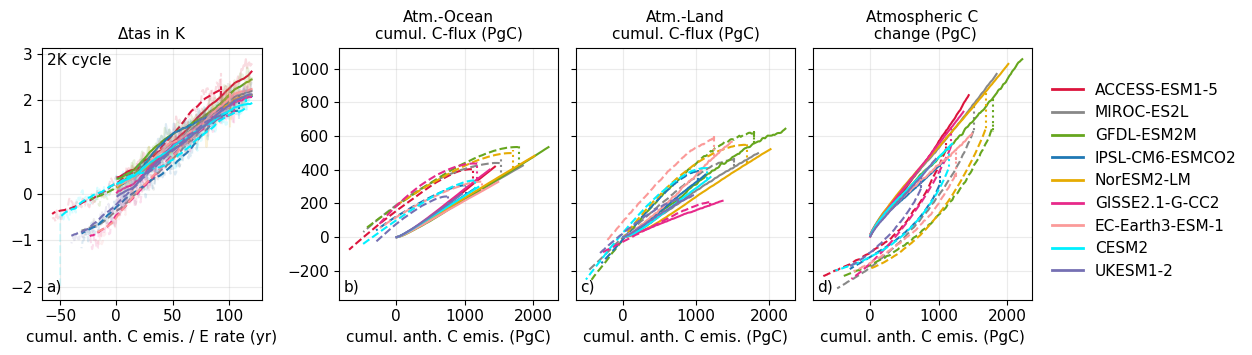

Nothing to plot for tas, NorESM2-LM, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global mean.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for nbp, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.


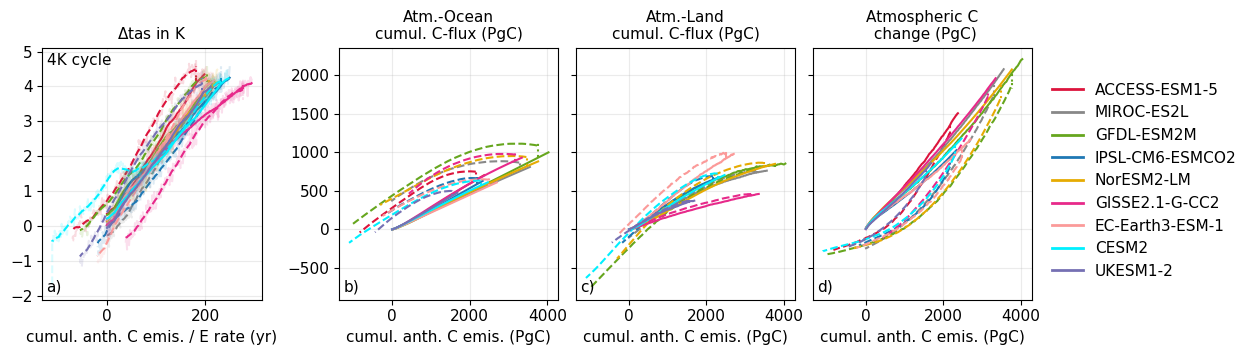

In [14]:
from matplotlib.lines import Line2D
import cftime

running_mean_years = 31


run_cycles = dict()
run_cycles['2K'] = ['esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl2p0-50y-dn2p0']
run_cycles['4K'] = ['esm-up2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl4p0-50y-dn2p0']


for run_cycle in run_cycles.keys():

    plt.rcParams['font.size']=11
    fig = plt.figure(figsize=(12, 3.5))
    figtext_written = 0
    
    # ============================================================
    # layout
    # ============================================================
    
    gs = fig.add_gridspec(
        1,
        4,
        width_ratios=[1, 1, 1, 1],
        wspace=0.08,
    )
    
    # first axis independent
    ax1 = fig.add_subplot(gs[0, 0])
    
    # shared-y group
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2], sharey=ax2)
    ax4 = fig.add_subplot(gs[0, 3], sharey=ax2)
    
    # shift shared group rightward
    shift = 0.05
    
    for ax in [ax2, ax3, ax4]:
        pos = ax.get_position()
        ax.set_position([
            pos.x0 + shift,
            pos.y0,
            pos.width,
            pos.height,
        ])
    
    axes = [ax1, ax2, ax3, ax4]
    
    for ax in axes:
        pos = ax.get_position()
        ax.set_position([
            pos.x0 - 0.1,
            pos.y0 + 0.05,
            pos.width,
            pos.height -0.05,
        ])
    
    # put budget in 5th slot
    plot_varias = [
        "tas",
        "fgco2",
        "nbp",
        "co2mass",
    ]
    
    # ============================================================
    # formatting constants
    # ============================================================
    
    xlim = [-1000,4000]
    xticks = [-1000,0,1000,2000,3000,4000]
    
    # ============================================================
    # legend handles
    # ============================================================
    
    legend_handles = {}
    
    # ============================================================
    # plotting
    # ============================================================
    
    for ax, varia in zip(axes, plot_varias):
    
        is_tas = varia == "tas"
    
        for model in models:
    
            freq_input = get_freq_input(model)
            stat = get_stat(varia, model) if varia != "budget" else "sum"
    
            member = MODELgrabber.get_grabber(model).get_member()
    
            color = model_dict[model].color_id
    
            # clean legend handle once per model
            if model not in legend_handles:
    
                legend_handles[model] = Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    alpha=1,
                    label=model,
                )
    
            for run in run_cycles[run_cycle]:

                figtext = f'{run_cycle} cycle'
                    
                if figtext_written == 0:
                    axes[0].text(0.02,0.98,figtext,transform=axes[0].transAxes,va='top')
                    figtext_written += 1
                    
                try:
    
                    annual_stat = all_annual_stats[varia][model][run]
    
    
                    # ------------------------------------------------
                    # zero-crossing time from cumulative emissions
                    # ------------------------------------------------
                    
                    emissions = all_annual_stats["fco2antt"][model][run]

                    if run == 'esm-up2p0' and run_cycle == '2K':
                        annual_stat = annual_stat.isel(time=slice(None,120))
                        emissions = emissions.isel(time=slice(None,120))

                    if is_tas:
                        emissions = emissions / model_dict[model].emission_rate
                
                    #zero_time = first_zero_crossing(emissions)
    
                    # raw series
                    ax.plot(
                        emissions,
                        annual_stat,
                        alpha=0.15 if is_tas else 1,
                        color=color,
                        linestyle=run_dict[run].linestyle_id
                    )
    
                    # smoothed tas overlay
                    if is_tas:
    
                        smooth = annual_stat.rolling(
                            time=running_mean_years,
                            center=True,
                            min_periods=1,
                        ).mean()
    
                        ax.plot(
                            emissions,
                            smooth,
                            alpha=1,
                            color=color,
                            linestyle=run_dict[run].linestyle_id
                        )
    
                except Exception:
    
                    print(
                        f"Nothing to plot for "
                        f"{varia}, {model}, {member}, {run}, "
                        f"{freq_input}, global {stat}."
                    )
    
                # ------------------------------------------------
                # marker at net-zero year
                # ------------------------------------------------
        
        # ========================================================
        # formatting
        # ========================================================
    
        tsize = 11
    
        if varia == "tas":
            ax.set_title(r"$\Delta$tas in K", fontsize=tsize)
    
        elif varia == "fgco2":
            ax.set_title("Atm.-Ocean\ncumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "nbp":
            ax.set_title("Atm.-Land\ncumul. C-flux (PgC)", fontsize=tsize)
    
        elif varia == "co2mass":
            ax.set_title("Atmospheric C\n change (PgC)", fontsize=tsize)
    
        elif varia == "budget":
            ax.set_title(r"b)+c)+d)", fontsize=tsize)
    
        elif varia == "fco2antt":
            ax.set_title("Cumulated\n anth. emissions (PgC)", fontsize=tsize)
    
        ax.grid(alpha=0.25)
    
        #ax.set_xlim(xlim)
    
        #ax.set_xticks(xticks)
        #ax.set_xticklabels([1, 200, 400, 600])
    
        # y limits
        #if is_tas:
        #    ax.set_ylim([-1.1, 5])
    
        #else:
        #    ax.set_ylim([-1000, 4500])
    
        # suppress redundant y tick labels
        if varia not in ["fgco2", "tas"]:
            ax.tick_params(labelleft=False)
    
    for axi in axes:
        axi.set_xlabel(r'cumul. anth. C emis. (PgC)')
    axes[0].set_xlabel(r'cumul. anth. C emis. / E rate (yr)')

    for axi,lab in zip(axes,['a)','b)','c)','d)','e)','f)']):
        axi.text(0.02,0.02,lab,ha='left',va='bottom',transform=axi.transAxes)
    
    # ============================================================
    # legend
    # ============================================================
    
    fig.legend(
        handles=list(legend_handles.values()),
        loc="center left",
        bbox_to_anchor=(0.855, 0.5),
        frameon=False,
    )
    
    #plt.subplots_adjust(left=0.02,bottom=0.1)
    plt.savefig(f'./../03_plots/fundamental_time_series/carbon_changes_against_emissions_{run_cycle}cycle.png',dpi=200,transparent=True)
    plt.show()